In [13]:
# Biblioteker
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from scipy.stats import chi2
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import matplotlib.pyplot as plt


# if libaries are not installed, run the following command in terminal:
# pip install pandas numpy seaborn matplotlib statsmodels

In [14]:
# Indlæs data
GDP = pd.read_csv("Data/GDP.csv", skiprows=4)
ODR = pd.read_csv("Data/age-dependency-ratio-old.csv")
TFP = pd.read_csv("Data/total-factor-productivity.csv")
HC = pd.read_csv("Data/HC.csv")
PWT = pd.read_excel("Data/pwt110.xlsx", sheet_name="Data")
PWT = PWT[['country', 'year', 'ctfp', 'rgdpe', 'pop']].copy()
GEO = pd.read_excel("Data/geo_cepii.xls")
OPN = pd.read_csv("Data/Oppenness.csv", skiprows=4)
URB = pd.read_csv("Data/Urbanization.csv", skiprows=4)

# Sammensæt data
Formålet er at konstruere et tværsnitsdatasæt med ét datapunkt pr. land, hvor vi forklarer TFP-vækst fra 2002 til 2020 med initial ODR og kontroller fra 2002

In [15]:
# Relevante variable fra PWT
PWT = PWT[['country', 'year', 'ctfp', 'rgdpe', 'pop']].copy()

# Relevante geografiske variable
GEO = GEO[['country', 'lat', 'continent', 'landlocked', 'colonizer1', 'area']].copy()

# Afstand til ækvator
GEO['AbsLat'] = GEO['lat'].abs()

# Tidligere koloni
GEO['FormerColony'] = (GEO['colonizer1'] != '.').astype(int)

# Behold kun relevante variable
GEO = GEO[['country', 'AbsLat', 'continent', 'landlocked', 'FormerColony', 'area']]

# Trade openness i 2002
opn2002 = OPN[['Country Name', '2002']].copy()
opn2002.columns = ['country', 'TradeOpen2002']
opn2002['TradeOpen2002'] = pd.to_numeric(opn2002['TradeOpen2002'], errors='coerce')

# Urbanisering i 2002
urb2002 = URB[['Country Name', '2002']].copy()
urb2002.columns = ['country', 'Urban2002']
urb2002['Urban2002'] = pd.to_numeric(urb2002['Urban2002'], errors='coerce')

# HC i 2002 fra ny HC-fil
hc2002 = HC[['Country', '2002']].copy()
hc2002.columns = ['country', 'HC2002']
hc2002['HC2002'] = pd.to_numeric(hc2002['HC2002'], errors='coerce')

# BNP per capita
PWT['gdp_pc'] = PWT['rgdpe'] / PWT['pop']

# Initiale variable i 2002 fra PWT
base2002 = PWT[PWT['year'] == 2002][['country', 'ctfp', 'gdp_pc']].copy()
base2002.columns = ['country', 'TFP2002', 'GDPpc2002']

# Merge HC2002 ind
base2002 = pd.merge(base2002, hc2002, on='country', how='left')

# TFP i 2020
tfp2020 = PWT[PWT['year'] == 2020][['country', 'ctfp']].copy()
tfp2020.columns = ['country', 'TFP2020']

# Long-difference datasæt
Tvaersnit = pd.merge(base2002, tfp2020, on='country', how='inner')

# GrowthTFP
Tvaersnit['GrowthTFP'] = np.log(Tvaersnit['TFP2020']) - np.log(Tvaersnit['TFP2002'])

# ODR i 2002
odr2002 = ODR[ODR['Year'] == 2002][[
    'Entity',
    'Age dependency ratio, old (% of working-age population)'
]].copy()
odr2002.columns = ['country', 'ODR2002']

# Samlet tværsnit
Tvaersnit = pd.merge(Tvaersnit, odr2002, on='country', how='inner')
Tvaersnit = pd.merge(Tvaersnit, GEO, on='country', how='left')
Tvaersnit = pd.merge(Tvaersnit, opn2002, on='country', how='left')
Tvaersnit = pd.merge(Tvaersnit, urb2002, on='country', how='left')

# Log area
Tvaersnit['log_area'] = np.log(Tvaersnit['area'])

# Fjern manglende observationer
Tvaersnit = Tvaersnit.dropna()

# Fjern dubletter
Tvaersnit = Tvaersnit.drop_duplicates(subset='country', keep='first')

# Deskriptiv statistik

In [16]:
cols = [
    'GrowthTFP',
    'ODR2002',
    'GDPpc2002',
    'HC2002',
    'landlocked',
    'FormerColony',
    'area',
    'TradeOpen2002',
    'Urban2002'
]

desc = Tvaersnit[cols].describe().round(2)

desc.loc['count'] = desc.loc['count'].astype(int)

print(desc)
print(desc.to_latex(float_format="%.2f"))

       GrowthTFP  ODR2002  GDPpc2002  HC2002  landlocked  FormerColony  \
count      91.00    91.00      91.00   91.00       91.00          91.0   
mean       -0.02    12.74   19081.67    2.48        0.16           0.8   
std         0.27     7.87   18097.60    0.65        0.37           0.4   
min        -0.52     1.58    1048.42    1.09        0.00           0.0   
25%        -0.23     6.04    4776.91    2.07        0.00           1.0   
50%        -0.05     8.79   11654.84    2.54        0.00           1.0   
75%         0.17    20.64   34026.38    2.96        0.00           1.0   
max         0.94    28.06   84592.23    3.58        1.00           1.0   

             area  TradeOpen2002  Urban2002  
count       91.00          91.00      91.00  
mean    836842.15          79.54      61.16  
std    1870328.28          47.81      21.44  
min        316.00          20.45      14.61  
25%      64944.50          53.30      43.47  
50%     267667.00          67.52      64.06  
75%     613

In [17]:
#print landene i datasættet
print("Countries in the dataset:")
for country in Tvaersnit['country']:
    print(country)
    

Countries in the dataset:
Angola
Albania
Argentina
Armenia
Australia
Austria
Benin
Burkina Faso
Bulgaria
Bahrain
Brazil
Botswana
Central African Republic
Canada
Switzerland
Chile
China
Cameroon
Colombia
Costa Rica
Cyprus
Germany
Denmark
Dominican Republic
Ecuador
Spain
Estonia
Finland
France
Gabon
United Kingdom
Greece
Guatemala
Honduras
Croatia
Hungary
Indonesia
India
Ireland
Iraq
Iceland
Israel
Italy
Jordan
Japan
Kenya
Kuwait
Sri Lanka
Lithuania
Luxembourg
Latvia
Morocco
Mexico
Malta
Mongolia
Mozambique
Mauritania
Mauritius
Malaysia
Namibia
Niger
Nicaragua
Netherlands
Norway
New Zealand
Panama
Peru
Philippines
Poland
Portugal
Paraguay
Qatar
Romania
Rwanda
Saudi Arabia
Sudan
Senegal
Singapore
Sierra Leone
El Salvador
Slovenia
Sweden
Togo
Thailand
Tajikistan
Tunisia
Ukraine
Uruguay
South Africa
Zambia
Zimbabwe


In [28]:
GEO = GEO[['country', 'AbsLat', 'continent', 'landlocked', 'FormerColony', 'area']]
Tvaersnit = pd.merge(Tvaersnit, GEO, on='country', how='left')

In [29]:
Tvaersnit["continent"]

0       Africa
1       Europe
2      America
3         Asia
4      Pacific
        ...   
104     Africa
105     Africa
106     Africa
107     Africa
108     Africa
Name: continent, Length: 109, dtype: object

In [30]:
Tvaersnit["region"] = Tvaersnit["continent"]

print(Tvaersnit["region"].isna().sum())

0


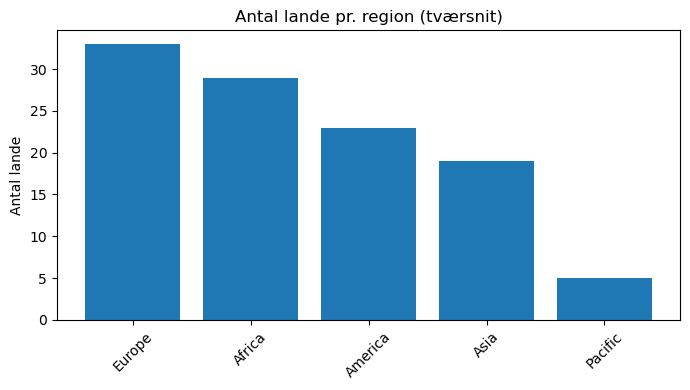

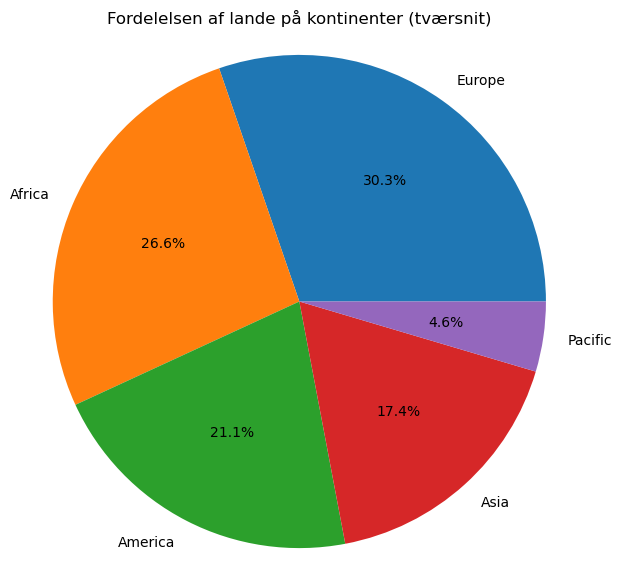

In [34]:
region_counts = Tvaersnit["region"].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(region_counts.index, region_counts.values)

plt.title("Antal lande pr. region (tværsnit)")
plt.ylabel("Antal lande")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#plottes også som cirkeldiagram
plt.figure(figsize=(7,7))
labels = region_counts.index
sizes = region_counts.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Fordelelsen af lande på kontinenter (tværsnit)")
plt.axis('equal')
plt.show()


# Tabel 1: ODR + Geografi

In [ ]:
# Klargør datasæt
df_model = Tvaersnit[[
    'country',
    'GrowthTFP',
    'ODR2002',
    'Urban2002',
    'AbsLat',
    'TradeOpen2002',
    'landlocked',
    'FormerColony',
    'HC2002',
    'GDPpc2002',
    'TFP2002',
    'log_area'
]].dropna().copy()

# Log-variable
df_model['log_GDPpc2002'] = np.log(df_model['GDPpc2002'])

Tvaersnit['log_area'] = np.log(Tvaersnit['area'])

# Antal lande og observationer
antal_lande = df_model['country'].nunique()
antal_observationer = df_model.shape[0]

# Automatisk print
print("=" * 80)
print("MODEL:")
print("GrowthTFP = α + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + ε")
print(f"Antal lande: {antal_lande}")
print(f"Antal observationer: {antal_observationer}")
print("=" * 80)

# Afhængig variabel
y = df_model['GrowthTFP']

# Model (1): Kun ODR
X1 = sm.add_constant(df_model[['ODR2002']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# model (2): ODR + Geografi
X2 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'log_area']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')


# Tabel
results = summary_col(
    [model1, model2],
    stars=True,
    model_names=['(1)', '(2)'],
    regressor_order=['ODR2002', 'landlocked', 'AbsLat', 'FormerColony', 'log_area', 'log_GDPpc2002', 'HC2002', 'TFP2002', 'Urban2002', 'TradeOpen2002', 'Europe', 'Asia', 'Africa', 'LatinAmerica', 'NorthAmerica', 'Oceania', 'MiddleEast'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)

print(results.as_latex())

MODEL:
GrowthTFP = α + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + ε
Antal lande: 91
Antal observationer: 91

                  (1)        (2)   
-----------------------------------
ODR2002        -0.0091*** -0.0078**
               (0.0031)   (0.0039) 
landlocked                -0.0370  
                          (0.0887) 
FormerColony              0.0343   
                          (0.0659) 
log_area                  0.0223*  
                          (0.0118) 
R-squared      0.0693     0.0987   
R-squared Adj. 0.0589     0.0568   
N              91         91       
R2             0.069      0.099    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lll}
\hline
               & (1)        & (2)        \\
\hline
ODR2002        & -0.0091*** & -0.0078**  \\
               & (0.0031)   & (0.0039)   \\
landlocked     &            & -0.0370    \\
               &            & (0.0887)   \\
Former

# Appendix tabel med Abslat

In [ ]:
# Klargør datasæt
df_model = Tvaersnit[[
    'country',
    'GrowthTFP',
    'ODR2002',
    'Urban2002',
    'AbsLat',
    'TradeOpen2002',
    'landlocked',
    'FormerColony',
    'HC2002',
    'GDPpc2002',
    'TFP2002',
    'log_area'
]].dropna().copy()

# Log-variable
df_model['log_GDPpc2002'] = np.log(df_model['GDPpc2002'])

# Antal lande og observationer
antal_lande = df_model['country'].nunique()
antal_observationer = df_model.shape[0]

# Automatisk print
print("=" * 90)
print("MODEL:")
print("GrowthTFP = α + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + β5 AbsLat + ε")
print(f"Antal lande: {antal_lande}")
print(f"Antal observationer: {antal_observationer}")
print("=" * 90)

# Afhængig variabel
y = df_model['GrowthTFP']

# Model (1): Kun ODR
X1 = sm.add_constant(df_model[['ODR2002']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# model (2): ODR + Geografi
X2 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# model (3): ODR + Geografi + GDP per capita
X3 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'log_area', 'AbsLat']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# Tabel
results = summary_col(
    [model1, model2, model3],
    stars=True,
    model_names=['(1)', '(2)', '(3)'],
    regressor_order=['ODR2002', 'landlocked', 'FormerColony', 'log_area', 'AbsLat', 'log_GDPpc2002', 'HC2002', 'TFP2002', 'Urban2002', 'TradeOpen2002', 'Europe', 'Asia', 'Africa', 'LatinAmerica', 'NorthAmerica', 'Oceania', 'MiddleEast'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)

print(results.as_latex())

MODEL:
GrowthTFP = α + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + β5 AbsLat + ε
Antal lande: 91
Antal observationer: 91

                  (1)        (2)      (3)   
--------------------------------------------
ODR2002        -0.0091*** -0.0091** -0.0063 
               (0.0031)   (0.0040)  (0.0063)
landlocked                -0.0434   -0.0337 
                          (0.0875)  (0.0895)
FormerColony              0.0094    0.0350  
                          (0.0660)  (0.0668)
log_area                            0.0224* 
                                    (0.0120)
AbsLat                              -0.0008 
                                    (0.0027)
R-squared      0.0693     0.0730    0.0998  
R-squared Adj. 0.0589     0.0410    0.0469  
N              91         91        91      
R2             0.069      0.073     0.100   
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{llll}
\hline
    

# ODR + GDP

In [ ]:
# Klargør datasæt
df_model = Tvaersnit[[
    'country',
    'GrowthTFP',
    'ODR2002',
    'Urban2002',
    'AbsLat',
    'TradeOpen2002',
    'landlocked',
    'FormerColony',
    'HC2002',
    'GDPpc2002',
    'TFP2002',
    'log_area'
]].dropna().copy()

# Log-variable
df_model['log_GDPpc2002'] = np.log(df_model['GDPpc2002'])

# Antal lande og observationer
antal_lande = df_model['country'].nunique()
antal_observationer = df_model.shape[0]

# Automatisk print
print("=" * 110)
print("MODEL:")
print("GrowthTFP = α + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + β5 HC2002 + β6 Urban2002 + β7 TradeOpen2002 + β8 log_GDPpc2002 + β9 TFP2002+ ε")
print(f"Antal lande: {antal_lande}")
print(f"Antal observationer: {antal_observationer}")
print("=" * 110)

# Afhængig variabel
y = df_model['GrowthTFP']

# Model (1): Kun ODR
X1 = sm.add_constant(df_model[['ODR2002']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# model (2): ODR + Geografi
X2 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony','HC2002', 'Urban2002', 'TradeOpen2002']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# model (3): ODR + Geografi + GDP per capita
X3 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'HC2002', 'Urban2002', 'TradeOpen2002', 'log_GDPpc2002']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# model (4): ODR + Geografi + GDP per capita + HC20002 + mekanismer 
X4 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'log_GDPpc2002', 'HC2002', 'Urban2002', 'TradeOpen2002', 'TFP2002']])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# Tabel
results = summary_col(
    [model1, model2, model3, model4],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)'],
    regressor_order=['ODR2002', 'landlocked', 'AbsLat', 'FormerColony', 'log_area', 'HC2002', 'Urban2002', 'TradeOpen2002', 'log_GDPpc2002', 'TFP2002'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)

print(results.as_latex())

MODEL:
GrowthTFP = α + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + β5 HC2002 + β6 Urban2002 + β7 TradeOpen2002 + β8 log_GDPpc2002 + β9 TFP2002+ ε
Antal lande: 91
Antal observationer: 91

                  (1)        (2)       (3)        (4)    
---------------------------------------------------------
ODR2002        -0.0091*** -0.0139** -0.0079    0.0017    
               (0.0031)   (0.0054)  (0.0050)   (0.0054)  
landlocked                -0.0363   -0.0963    -0.0836   
                          (0.0908)  (0.0819)   (0.0685)  
FormerColony              0.0154    -0.1079*   -0.0814   
                          (0.0682)  (0.0615)   (0.0503)  
HC2002                    0.0740    0.1720**   0.0633    
                          (0.0844)  (0.0830)   (0.0811)  
Urban2002                 0.0003    0.0065***  0.0027    
                          (0.0018)  (0.0021)   (0.0018)  
TradeOpen2002             -0.0005   0.0005     0.0005    
                          (0.0005)  (0.000

# Regionale dummies

In [ ]:
# Klargør datasæt
df_model = Tvaersnit[[
    'country',
    'GrowthTFP',
    'ODR2002',
    'Urban2002',
    'AbsLat',
    'TradeOpen2002',
    'landlocked',
    'FormerColony',
    'HC2002',
    'GDPpc2002',
    'TFP2002',
    'log_area'
]].dropna().copy()

# Log-variable
df_model['log_GDPpc2002'] = np.log(df_model['GDPpc2002'])

# Antal lande og observationer
antal_lande = df_model['country'].nunique()
antal_observationer = df_model.shape[0]

# Automatisk print
print("=" * 80)
print("MODEL:")
print("GrowthTFP = α + β1 ODR2002 + β2 TradeOpen2002 + β3 Urban2002 + β4 landlocked + ε")
print(f"Antal lande: {antal_lande}")
print(f"Antal observationer: {antal_observationer}")
print("=" * 80)

# Regioner
europe = [
    'Albania','Austria','Belgium','Bulgaria','Croatia','Cyprus','Czechia','Denmark','Estonia','Finland','France','Germany',
    'Greece','Hungary','Iceland','Ireland','Italy','Latvia','Lithuania','Luxembourg','Malta','Netherlands','Norway',
    'Poland','Portugal','Romania','Serbia','Slovakia','Slovenia','Spain','Sweden','Switzerland','Ukraine','United Kingdom','Armenia']

asia = [
    'Bahrain','China','India','Indonesia','Iraq','Israel','Japan','Jordan','Kazakhstan','Kuwait','Kyrgyzstan','Malaysia',
    'Mongolia','Philippines','Qatar','Saudi Arabia','Singapore','Sri Lanka','Taiwan','Tajikistan','Thailand']

africa = [
    'Angola','Benin','Botswana','Burkina Faso','Burundi','Cameroon','Central African Republic','Egypt','Eswatini',
    'Gabon','Kenya','Lesotho','Mauritania','Mauritius','Morocco','Mozambique','Namibia','Niger','Nigeria',
    'Rwanda','Senegal','Sierra Leone','South Africa','Sudan','Togo','Tunisia','Zambia','Zimbabwe']

latin_america = [
    'Argentina','Barbados','Brazil','Chile','Colombia','Costa Rica','Dominican Republic','Ecuador','El Salvador',
    'Guatemala','Honduras','Jamaica','Mexico','Nicaragua','Panama','Paraguay','Peru','Trinidad and Tobago','Uruguay']

north_america = ['Canada', 'United States']

oceania = ['Australia', 'Fiji', 'New Zealand']

middle_east = ['Bahrain', 'Iraq', 'Israel', 'Jordan', 'Kuwait', 'Qatar', 'Saudi Arabia']

# Regionale dummies
df_model['Europe'] = df_model['country'].isin(europe).astype(int)
df_model['Asia'] = df_model['country'].isin(asia).astype(int)
df_model['Africa'] = df_model['country'].isin(africa).astype(int)
df_model['LatinAmerica'] = df_model['country'].isin(latin_america).astype(int)
df_model['NorthAmerica'] = df_model['country'].isin(north_america).astype(int)
df_model['Oceania'] = df_model['country'].isin(oceania).astype(int)
df_model['MiddleEast'] = df_model['country'].isin(middle_east).astype(int)

# Afhængig variabel
y = df_model['GrowthTFP']

# Model (1): Kun ODR
X1 = sm.add_constant(df_model[['ODR2002']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# model (2): ODR + Geografi
X2 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony','HC2002', 'Urban2002', 'TradeOpen2002']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# model (3): ODR + Geografi + GDP per capita
X3 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'HC2002', 'Urban2002', 'TradeOpen2002', 'Europe', 'Asia', 'Africa', 'LatinAmerica', 'NorthAmerica', 'Oceania', 'MiddleEast']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# model (5): ODR + Geografi + GDP per capita + HC20002 + mekanismer + regioner
X4 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'log_GDPpc2002', 'HC2002', 'Urban2002', 'TradeOpen2002', 'Europe', 'Asia', 'Africa', 'LatinAmerica', 'NorthAmerica', 'Oceania', 'MiddleEast']])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# model (6): ODR + Geografi + GDP per capita + HC20002 + mekanismer + regioner
X5 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'log_GDPpc2002', 'HC2002', 'Urban2002', 'TradeOpen2002', 'Europe', 'Asia', 'Africa', 'LatinAmerica', 'NorthAmerica', 'Oceania', 'MiddleEast', 'TFP2002']])
model5 = sm.OLS(y, X5).fit(cov_type='HC1')

# Tabel
results = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)'],
    regressor_order=['ODR2002', 'landlocked', 'AbsLat', 'FormerColony', 'log_area', 'HC2002', 'Urban2002', 'TradeOpen2002', 'Europe', 'Asia', 'Africa', 'LatinAmerica', 'NorthAmerica', 'Oceania', 'MiddleEast', 'log_GDPpc2002', 'TFP2002'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)

print(results.as_latex())

MODEL:
GrowthTFP = α + β1 ODR2002 + β2 TradeOpen2002 + β3 Urban2002 + β4 landlocked + ε
Antal lande: 91
Antal observationer: 91

                  (1)        (2)       (3)       (4)        (5)    
-------------------------------------------------------------------
ODR2002        -0.0091*** -0.0139** -0.0179*  -0.0125*   -0.0056   
               (0.0031)   (0.0054)  (0.0096)  (0.0074)   (0.0077)  
landlocked                -0.0363   -0.0282   -0.0946    -0.1140   
                          (0.0908)  (0.0928)  (0.0894)   (0.0796)  
FormerColony              0.0154    0.0524    -0.0806    -0.1128*  
                          (0.0682)  (0.0763)  (0.0723)   (0.0614)  
HC2002                    0.0740    0.0584    0.1551*    0.1097    
                          (0.0844)  (0.0946)  (0.0892)   (0.0811)  
Urban2002                 0.0003    0.0034    0.0089***  0.0039    
                          (0.0018)  (0.0028)  (0.0030)   (0.0025)  
TradeOpen2002             -0.0005   -0.0012*  -0.0001  